In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [20]:
df_2018_hm = pd.read_csv('2018_season_quali_dataset.csv')

In [25]:
df_2025_hm = pd.read_csv('2025_season_quali_dataset.csv')

### Qualifying Position - Heatmap

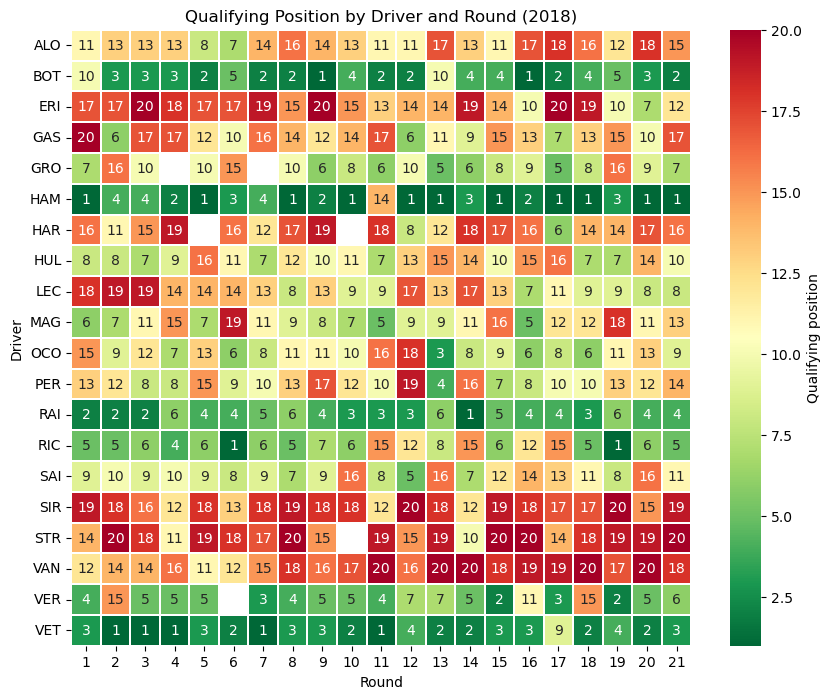

In [28]:
quali_2018_pos = df_2018_hm.pivot(index='Driver', columns='Round', values='Quali_Position')
plt.figure(figsize=(10, 8))

sns.heatmap(
    quali_2018_pos,
    cmap='RdYlGn_r', 
    lw=0.3,
    linecolor='white',
    annot=True,          
    cbar_kws={'label': 'Qualifying position'})

plt.title('Qualifying Position by Driver and Round (2018)')
plt.xlabel('Round')
plt.ylabel('Driver')

#plt.show()

plt.savefig('Quali_Pos_HM_2018.png')

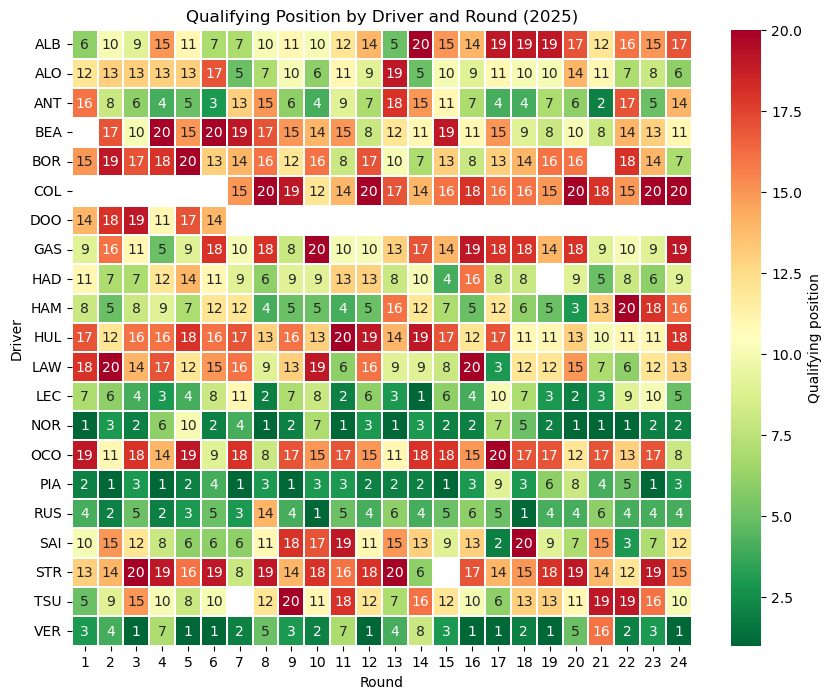

In [29]:
quali_2025_pos = df_2025_hm.pivot(index='Driver', columns='Round', values='Quali_Position')
plt.figure(figsize=(10, 8))

sns.heatmap(
    quali_2025_pos,
    cmap='RdYlGn_r', 
    lw=0.3,
    linecolor='white',
    annot=True,          
    cbar_kws={'label': 'Qualifying position'})

plt.title('Qualifying Position by Driver and Round (2025)')
plt.xlabel('Round')
plt.ylabel('Driver')

#plt.show()

plt.savefig('Quali_Pos_HM_2025.png')

### Pole Gap Position - Heatmap

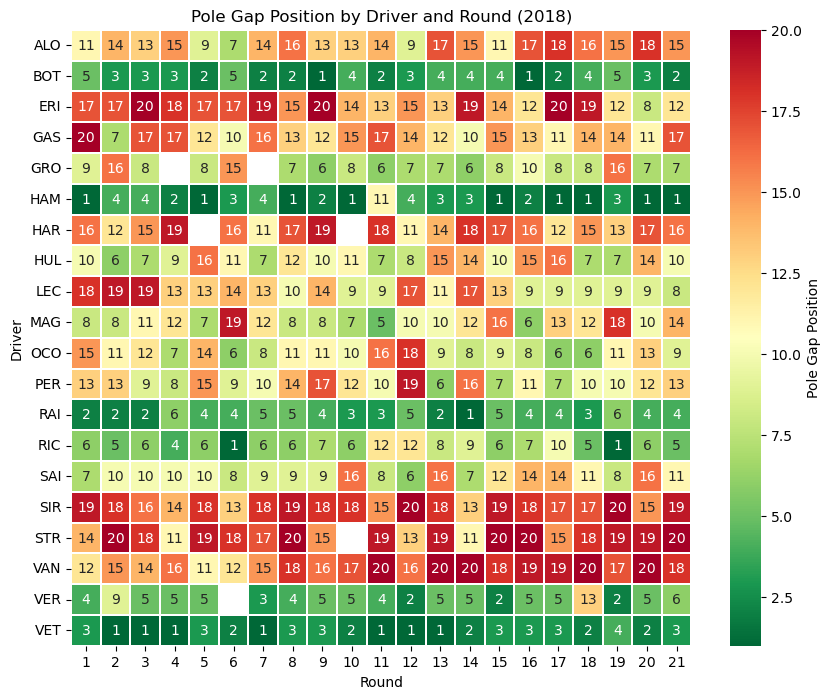

In [30]:
quali_2018_pg_pos = df_2018_hm.pivot(index='Driver', columns='Round', values='Pole_Gap_Position')
plt.figure(figsize=(10, 8))

sns.heatmap(
    quali_2018_pg_pos,
    cmap='RdYlGn_r', 
    lw=0.3,
    linecolor='white',
    annot=True,          
    cbar_kws={'label': 'Pole Gap Position'})

plt.title('Pole Gap Position by Driver and Round (2018)')
plt.xlabel('Round')
plt.ylabel('Driver')

#plt.show()

plt.savefig('Quali_Pole_Gap_Pos_HM_2018.png')

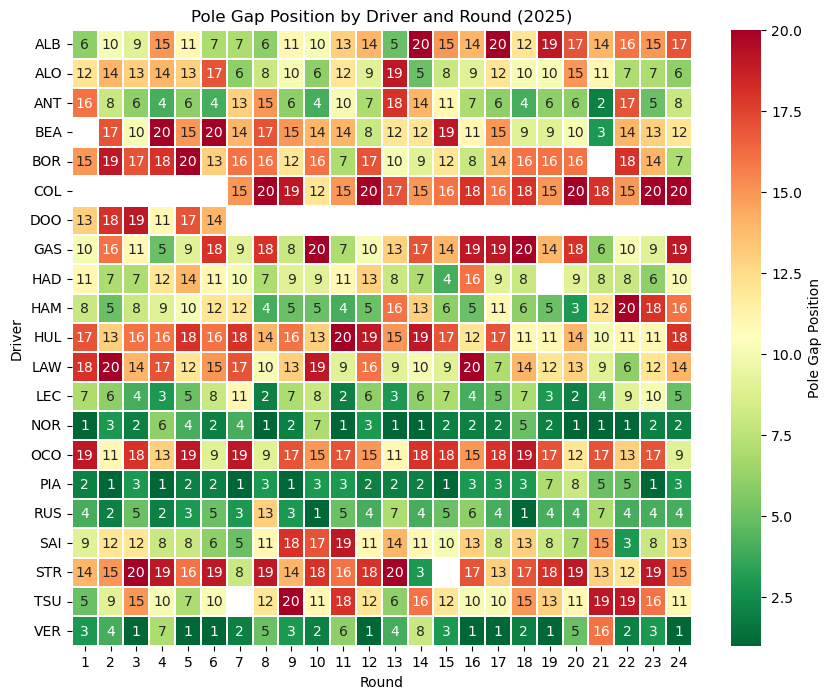

In [31]:
quali_2025_pg_pos = df_2025_hm.pivot(index='Driver', columns='Round', values='Pole_Gap_Position')
plt.figure(figsize=(10, 8))

sns.heatmap(
    quali_2025_pg_pos,
    cmap='RdYlGn_r', 
    lw=0.3,
    linecolor='white',
    annot=True,          
    cbar_kws={'label': 'Pole Gap Position'})

plt.title('Pole Gap Position by Driver and Round (2025)')
plt.xlabel('Round')
plt.ylabel('Driver')

#plt.show()

plt.savefig('Quali_Pole_Gap_Pos_HM_2025.png')

### Position Difference - Heatmap

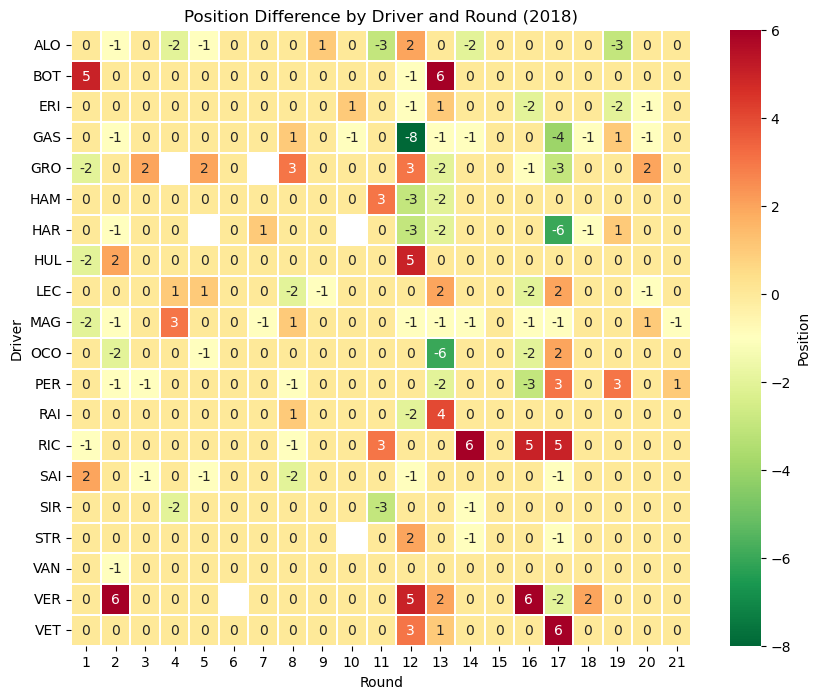

In [34]:
df_2018_hm['Position_Difference'] = df_2018_hm['Quali_Position'] - df_2018_hm['Pole_Gap_Position'] # difference between official quali position and pole gap position

dif_pos_2018 = df_2018_hm.pivot(index='Driver', columns='Round', values='Position_Difference')

plt.figure(figsize=(10, 8))

sns.heatmap(
    dif_pos_2018,
    cmap='RdYlGn_r',
    lw=0.3,
    linecolor='white',
    annot=True,          
    cbar_kws={'label': 'Position'})

plt.title('Position Difference by Driver and Round (2018)')
plt.xlabel('Round')
plt.ylabel('Driver')

#plt.show()

plt.savefig('Quali_Pos_Dif_HM_2018.png')

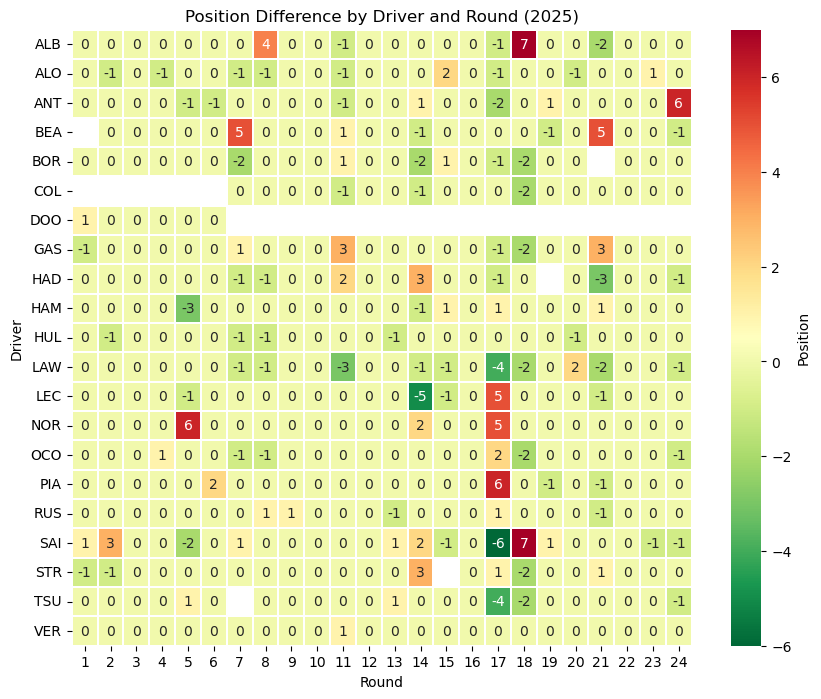

In [35]:
df_2025_hm['Position_Difference'] = df_2025_hm['Quali_Position'] - df_2025_hm['Pole_Gap_Position'] # difference between official quali position and pole gap position

dif_pos_2025 = df_2025_hm.pivot(index='Driver', columns='Round', values='Position_Difference')

plt.figure(figsize=(10, 8))

sns.heatmap(
    dif_pos_2025,
    cmap='RdYlGn_r',
    lw=0.3,
    linecolor='white',
    annot=True,          
    cbar_kws={'label': 'Position'})

plt.title('Position Difference by Driver and Round (2025)')
plt.xlabel('Round')
plt.ylabel('Driver')

#plt.show()

plt.savefig('Quali_Pos_Dif_HM_2025.png')

In [37]:
df_perc_infl = pd.DataFrame({
    'Season': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Driver': [0.99, 1.77, 0.40, 2.28, 0.95, 2.77, 2.97, 8.34],
    'Constructor': [87.59, 88.80, 44.40, 45.26, 50.57, 28.17, 52.31, 60.27],
    'Round': [0.46, 2.30, 19.43, 2.80, 17.24, 14.62, 11.10, 12.76],
    'Sigma': [10.96, 7.13, 35.77, 49.67, 31.24, 54.44, 33.63, 18.62]})

df_perc_infl = df_perc_infl.set_index('Season')

### Relative Influence - Stacked Bar Chart

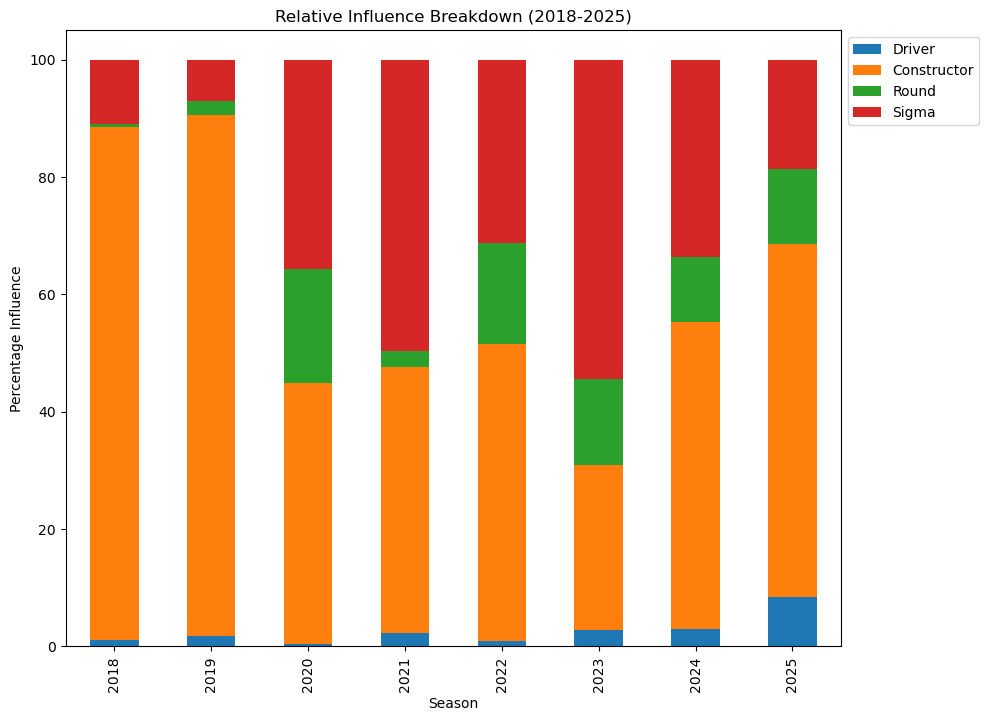

In [38]:
df_perc_infl.plot(kind='bar', stacked=True, figsize=(10, 8))

plt.ylabel('Percentage Influence')
plt.xlabel('Season')
plt.title('Relative Influence Breakdown (2018-2025)')
plt.legend(bbox_to_anchor=(1, 1))

#plt.show()

plt.savefig('Realtive_Influence_SBG.png')

### Relative Influence - Line Graph

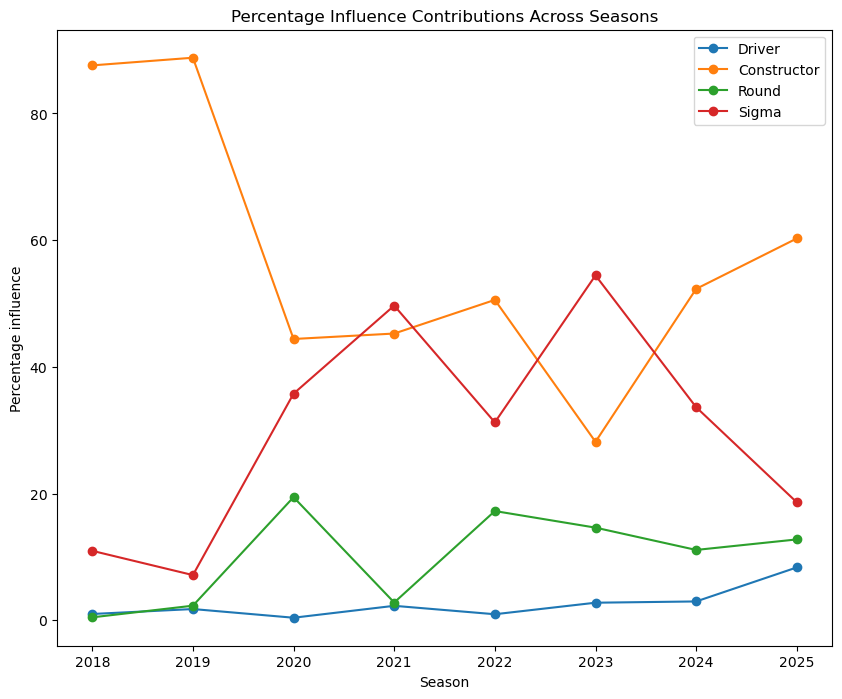

In [39]:
plt.figure(figsize=(10, 8))

for col in df_perc_infl.columns:
    plt.plot(df_perc_infl.index, df_perc_infl[col], marker='o', label=col)

plt.legend()
plt.ylabel('Percentage influence')
plt.xlabel('Season')
plt.title('Percentage Influence Contributions Across Seasons')

#plt.show()

plt.savefig('Realtive_Influence_LG.png')

### Driver Effect in Qualifying & Race (2018) - Line Graph

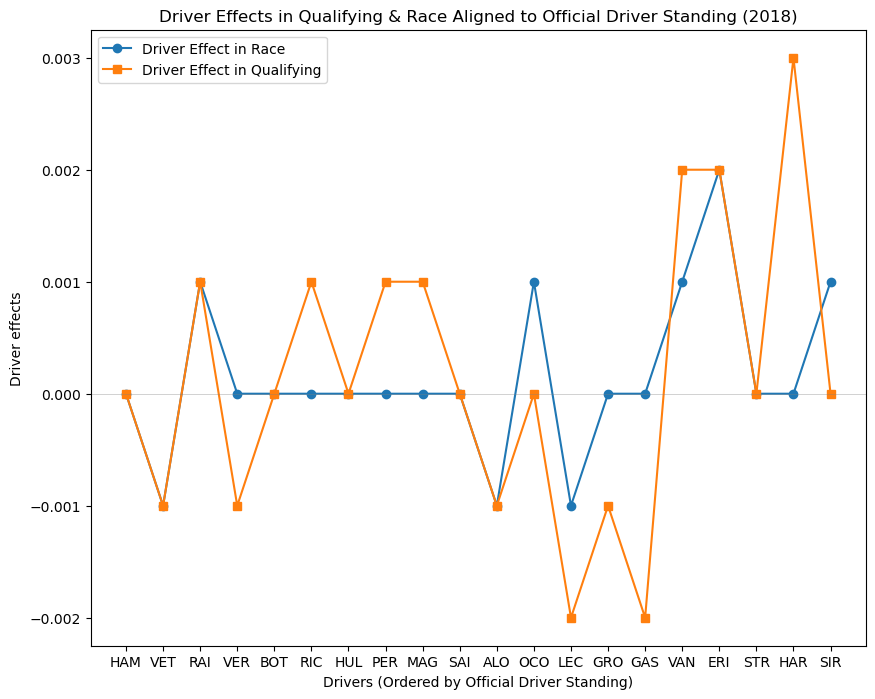

In [40]:
df_qe_2018 = pd.read_csv('driver_race_quali_eff_graph_2018.csv')

plt.figure(figsize=(10, 8))

plt.plot(df_qe_2018['Standing'], df_qe_2018['Driver_Effect_Race'], label='Driver Effect in Race', marker='o')
plt.plot(df_qe_2018['Standing'], df_qe_2018['Driver_Effect_Quali'], label='Driver Effect in Qualifying', marker='s')

plt.axhline(0, color='grey', lw=0.5, alpha=0.5)

plt.legend()
plt.xlabel('Drivers (Ordered by Official Driver Standing)')
plt.ylabel('Driver effects')
plt.title('Driver Effects in Qualifying & Race Aligned to Official Driver Standing (2018)')
plt.xticks(df_qe_2018['Standing'], df_qe_2018['Driver'])

#plt.show()

plt.savefig('Driver_eff_QR_LG_2018.png')

### Driver Effect in Qualifying & Race (2025) - Line Graph

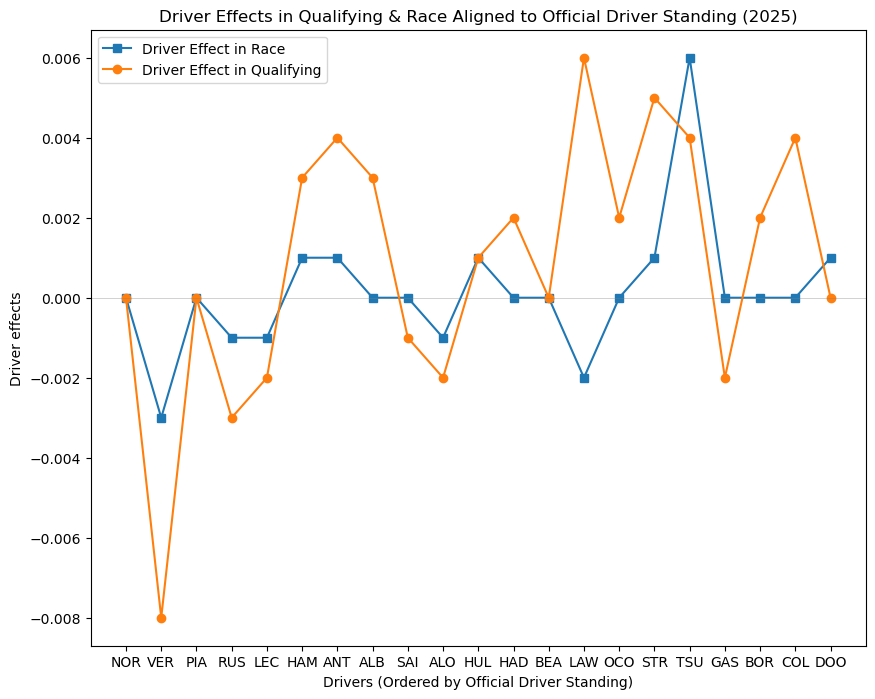

In [41]:
df_qe_2025 = pd.read_csv('driver_race_quali_eff_graph_2025.csv')

plt.figure(figsize=(10, 8))

plt.plot(df_qe_2025['Standing'], df_qe_2025['Driver_Effect_Race'], label='Driver Effect in Race', marker='s')
plt.plot(df_qe_2025['Standing'], df_qe_2025['Driver_Effect_Quali'], label='Driver Effect in Qualifying', marker='o')

plt.axhline(0, color='grey', linewidth=0.5, alpha=0.5)

plt.legend()
plt.xlabel('Drivers (Ordered by Official Driver Standing)')
plt.ylabel('Driver effects')
plt.title('Driver Effects in Qualifying & Race Aligned to Official Driver Standing (2025)')
plt.xticks(df_qe_2025['Standing'], df_qe_2025['Driver'])

#plt.show()

plt.savefig('Driver_eff_QR_LG_2025.png')

### Driver Constructor Paired Effects (2018) - Scatterplot

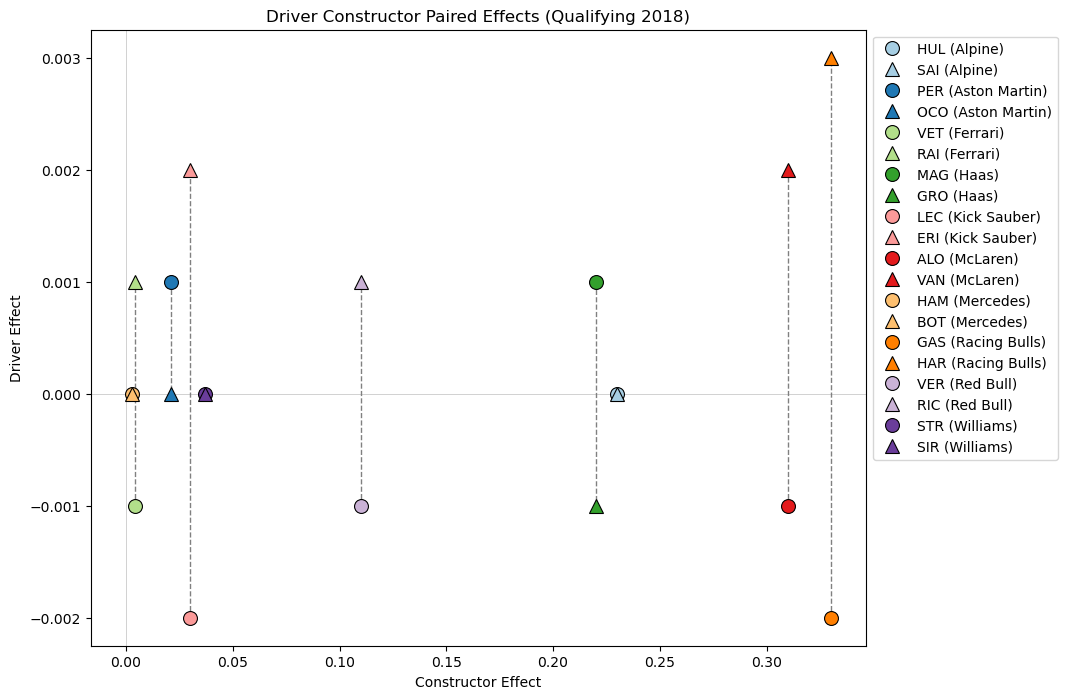

In [42]:
df_2025 = pd.read_csv('driver_constructor_pair_ef_graph_2018.csv')

fig, ax = plt.subplots(figsize=(10, 8))

colours = mpl.color_sequences['Paired']
markers = ('o', '^', 's')

plt.axhline(0, color='grey', lw=0.5, alpha=0.5)
plt.axvline(0, color='grey', lw=0.5, alpha=0.5)

constructor_groups = df_2025.groupby('Constructor')

for i, (constructor, drivers) in enumerate(constructor_groups):
    colour = colours[i]
    ax.plot(drivers['Constructor_Effect'], drivers['Driver_Effect'], ls='--', color='grey', lw=1)
    for index, driver in enumerate(drivers.itertuples(index=False)):
        ax.plot(driver.Constructor_Effect, driver.Driver_Effect, label = f'{driver.Driver} ({constructor})', marker = markers[index], ms = 10, mec = 'black', mew = 0.8, mfc = colour, lw=0)

plt.legend(bbox_to_anchor=(1, 1))
plt.xlabel('Constructor Effect')
plt.ylabel('Driver Effect')
plt.title('Driver Constructor Paired Effects (Qualifying 2018)')

#plt.show()

plt.savefig('DC_Paired_eff_SG_2018.png')

### Driver Constructor Paired Effects (2025) - Scatterplot

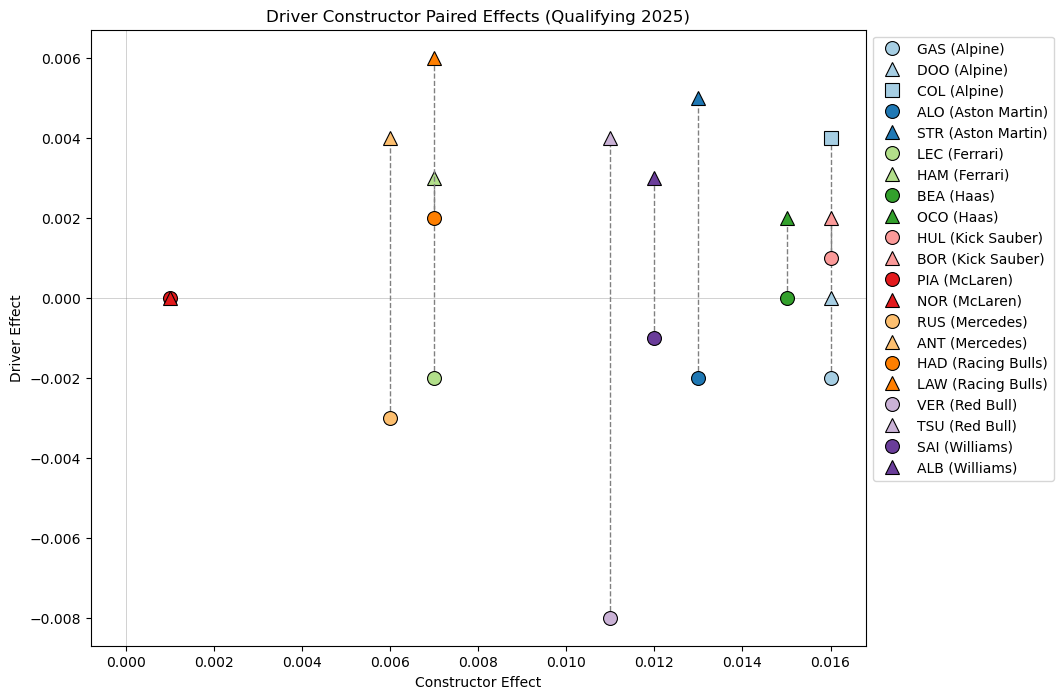

In [43]:
df_2025 = pd.read_csv('driver_constructor_pair_ef_graph_2025.csv')

fig, ax = plt.subplots(figsize=(10, 8))

colours = mpl.color_sequences['Paired']
markers = ('o', '^', 's')

plt.axhline(0, color='grey', lw=0.5, alpha=0.5)
plt.axvline(0, color='grey', lw=0.5, alpha=0.5)

constructor_groups = df_2025.groupby('Constructor')

for i, (constructor, drivers) in enumerate(constructor_groups):
    colour = colours[i]
    ax.plot(drivers['Constructor_Effect'], drivers['Driver_Effect'], ls='--', color='grey', lw=1)
    for index, driver in enumerate(drivers.itertuples(index=False)):
        ax.plot(driver.Constructor_Effect, driver.Driver_Effect, label = f'{driver.Driver} ({constructor})', marker = markers[index], ms = 10, mec = 'black', mew = 0.8, mfc = colour, lw=0)

plt.legend(bbox_to_anchor=(1, 1))
plt.xlabel('Constructor Effect')
plt.ylabel('Driver Effect')
plt.title('Driver Constructor Paired Effects (Qualifying 2025)')

#plt.show()

plt.savefig('DC_Paired_eff_SG_2025.png')